# Advanced Analytics + Risk Metrics

**Deliverables generated by this notebook**
- `reports/advanced_analytics/var_cvar_report.csv`
- `reports/advanced_analytics/investor_cohort_analysis.csv`
- `reports/advanced_analytics/sip_continuity_report.csv`
- `reports/advanced_analytics/sector_hhi_concentration.csv`
- `reports/charts/rolling_sharpe_chart.png`

Run this notebook from your project root or from the `notebooks/` folder.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

SQRT_252 = np.sqrt(252)

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name.lower() == "notebooks" else cwd

DATA_DIRS = [
    PROJECT_ROOT / "data" / "processed",
    PROJECT_ROOT / "data" / "raw",
    PROJECT_ROOT / "notebooks" / "data" / "processed",
    PROJECT_ROOT / "notebooks" / "data" / "raw",
    PROJECT_ROOT
]

OUTPUT_DIR = PROJECT_ROOT / "reports" / "advanced_analytics"
CHART_DIR = PROJECT_ROOT / "reports" / "charts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output folder:", OUTPUT_DIR)
print("Charts folder:", CHART_DIR)

Project root: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics
Output folder: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\advanced_analytics
Charts folder: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\charts


In [2]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    # Standardize column names to lower_snake_case.
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    return df

def find_csv(alias_keywords):
    # Find a CSV file by checking whether alias keywords are in filename.
    csv_files = []
    for d in DATA_DIRS:
        if d.exists():
            csv_files.extend(list(d.glob("*.csv")))
    csv_files = sorted(set(csv_files))

    for f in csv_files:
        name_compact = f.stem.lower().replace("_", "").replace("-", "").replace(" ", "")
        for aliases in alias_keywords:
            aliases_joined = "".join(aliases).lower().replace("_", "").replace("-", "").replace(" ", "")
            if aliases_joined in name_compact:
                return f

    for f in csv_files:
        name = f.stem.lower()
        for aliases in alias_keywords:
            if all(a.lower() in name for a in aliases):
                return f
    return None

def load_table(label, alias_keywords, required=False):
    path = find_csv(alias_keywords)
    if path is None:
        msg = f"Could not find CSV for {label}. Tried aliases: {alias_keywords}"
        if required:
            raise FileNotFoundError(msg)
        print("WARNING:", msg)
        return pd.DataFrame()
    df = clean_columns(pd.read_csv(path))
    print(f"Loaded {label}: {path.name} | shape={df.shape}")
    return df

def pick_col(df, candidates, required=True, label="column"):
    for c in candidates:
        c_clean = (
            str(c).strip().lower()
            .replace(" ", "_")
            .replace("-", "_")
        )
        if c_clean in df.columns:
            return c_clean
    if required:
        raise KeyError(f"Missing {label}. Tried: {candidates}. Available: {list(df.columns)}")
    return None

def to_numeric_series(s):
    return pd.to_numeric(
        s.astype(str).str.replace(",", "", regex=False).str.replace("%", "", regex=False),
        errors="coerce"
    )

def parse_date_series(s):
    return pd.to_datetime(s, errors="coerce", dayfirst=True)

In [3]:
fund_master = load_table(
    "FundMaster",
    [["fundmaster"], ["fund", "master"], ["scheme", "master"]],
    required=False
)

nav_history = load_table(
    "NavHistory",
    [["navhistory"], ["nav", "history"], ["nav"]],
    required=True
)

investor_txn = load_table(
    "InvestorTransactions",
    [["investortransactions"], ["investor", "transactions"], ["transactions"], ["sip"]],
    required=False
)

scorecard = load_table(
    "FundScorecard",
    [["fundscorecard"], ["fund", "scorecard"], ["scorecard"]],
    required=False
)

scheme_perf = load_table(
    "SchemePerformance",
    [["schemeperformance"], ["scheme", "performance"], ["performance"]],
    required=False
)

sector_data = load_table(
    "Sector / Holdings Allocation",
    [["sectorallocation"], ["sector", "allocation"], ["portfolio", "holdings"], ["fund", "holdings"], ["holdings"]],
    required=False
)

Loaded FundMaster: 01_fund_master_clean.csv | shape=(40, 15)
Loaded NavHistory: 02_nav_history_clean.csv | shape=(46000, 3)
Loaded InvestorTransactions: 04_monthly_sip_inflows_clean.csv | shape=(48, 6)
Loaded SchemePerformance: 07_scheme_performance_clean.csv | shape=(40, 19)
Loaded Sector / Holdings Allocation: 09_portfolio_holdings_clean.csv | shape=(322, 8)


## 1. Historical VaR and CVaR at 95%

Formula:
- **VaR 95%** = 5th percentile of daily returns
- **CVaR 95%** = average return below the VaR threshold

In [4]:
nav_code_col = pick_col(nav_history, ["amfi_code", "scheme_code", "fund_code"], label="NAV fund code")
nav_date_col = pick_col(nav_history, ["date", "nav_date", "day"], label="NAV date")
nav_value_col = pick_col(nav_history, ["nav", "net_asset_value", "nav_value"], label="NAV value")

nav = nav_history.copy()
nav[nav_code_col] = nav[nav_code_col].astype(str).str.strip()
nav[nav_date_col] = parse_date_series(nav[nav_date_col])
nav[nav_value_col] = to_numeric_series(nav[nav_value_col])

nav = nav.dropna(subset=[nav_code_col, nav_date_col, nav_value_col])
nav = nav.sort_values([nav_code_col, nav_date_col])

nav["daily_return"] = nav.groupby(nav_code_col)[nav_value_col].pct_change()
returns = nav.dropna(subset=["daily_return"]).copy()

def cvar_95(x):
    threshold = x.quantile(0.05)
    below = x[x <= threshold]
    return below.mean() if len(below) else np.nan

var_cvar = (
    returns.groupby(nav_code_col)["daily_return"]
    .agg(
        observations="count",
        mean_daily_return="mean",
        std_daily_return="std",
        var_95=lambda x: x.quantile(0.05),
        cvar_95=cvar_95,
        worst_day_return="min",
        best_day_return="max"
    )
    .reset_index()
)

var_cvar["annualized_return_est"] = var_cvar["mean_daily_return"] * 252
var_cvar["annualized_volatility"] = var_cvar["std_daily_return"] * SQRT_252
var_cvar["sharpe_ratio"] = (
    var_cvar["mean_daily_return"] / var_cvar["std_daily_return"]
) * SQRT_252

if not fund_master.empty:
    fm = fund_master.copy()
    fm_code_col = pick_col(fm, ["amfi_code", "scheme_code", "fund_code"], required=False, label="FundMaster fund code")
    if fm_code_col:
        fm[fm_code_col] = fm[fm_code_col].astype(str).str.strip()
        keep_cols = [fm_code_col]
        for c in ["scheme_name", "fund_name", "name", "amc", "fund_house", "category", "scheme_category", "risk_grade", "risk"]:
            if c in fm.columns:
                keep_cols.append(c)
        meta = fm[keep_cols].drop_duplicates(subset=[fm_code_col])
        var_cvar = var_cvar.merge(meta, left_on=nav_code_col, right_on=fm_code_col, how="left")
        if fm_code_col != nav_code_col and fm_code_col in var_cvar.columns:
            var_cvar = var_cvar.drop(columns=[fm_code_col])

for extra_df in [scorecard, scheme_perf]:
    if not extra_df.empty:
        extra_code_col = pick_col(extra_df, ["amfi_code", "scheme_code", "fund_code"], required=False)
        if extra_code_col:
            temp = extra_df.copy()
            temp[extra_code_col] = temp[extra_code_col].astype(str).str.strip()
            extra_keep = [extra_code_col]
            for c in ["risk_grade", "risk", "sharpe_ratio", "sharpe", "category", "scheme_category"]:
                if c in temp.columns and c not in extra_keep:
                    extra_keep.append(c)
            temp = temp[extra_keep].drop_duplicates(subset=[extra_code_col])
            rename_map = {}
            for c in temp.columns:
                if c != extra_code_col and c in var_cvar.columns:
                    rename_map[c] = f"{c}_extra"
            temp = temp.rename(columns=rename_map)
            var_cvar = var_cvar.merge(temp, left_on=nav_code_col, right_on=extra_code_col, how="left")
            if extra_code_col != nav_code_col and extra_code_col in var_cvar.columns:
                var_cvar = var_cvar.drop(columns=[extra_code_col])

fund_name_col = None
for candidate in ["scheme_name", "fund_name", "name"]:
    if candidate in var_cvar.columns:
        fund_name_col = candidate
        break

if fund_name_col is None:
    var_cvar["fund_display_name"] = var_cvar[nav_code_col].astype(str)
else:
    var_cvar["fund_display_name"] = var_cvar[fund_name_col].fillna(var_cvar[nav_code_col].astype(str))

risk_col = None
for candidate in ["risk_grade", "risk", "risk_grade_extra", "risk_extra"]:
    if candidate in var_cvar.columns:
        risk_col = candidate
        break

if risk_col is None:
    valid_vol = var_cvar["annualized_volatility"].dropna()
    if len(valid_vol) >= 3:
        q1, q2 = valid_vol.quantile([0.33, 0.66])
        def risk_from_vol(v):
            if pd.isna(v):
                return "Moderate"
            if v <= q1:
                return "Low"
            if v <= q2:
                return "Moderate"
            return "High"
        var_cvar["risk_grade"] = var_cvar["annualized_volatility"].apply(risk_from_vol)
    else:
        var_cvar["risk_grade"] = "Moderate"
else:
    var_cvar["risk_grade"] = var_cvar[risk_col].astype(str).str.title()
    var_cvar["risk_grade"] = var_cvar["risk_grade"].replace({
        "Low Risk": "Low",
        "Moderate Risk": "Moderate",
        "Medium": "Moderate",
        "Medium Risk": "Moderate",
        "High Risk": "High"
    })

front_cols = [nav_code_col, "fund_display_name", "risk_grade", "observations", "var_95", "cvar_95", "sharpe_ratio", "annualized_volatility"]
remaining_cols = [c for c in var_cvar.columns if c not in front_cols]
var_cvar = var_cvar[front_cols + remaining_cols].sort_values("var_95")

var_cvar_path = OUTPUT_DIR / "var_cvar_report.csv"
var_cvar.to_csv(var_cvar_path, index=False)

print("Saved:", var_cvar_path)
display(var_cvar.head(10))

Saved: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\advanced_analytics\var_cvar_report.csv


,amfi_code,fund_display_name,risk_grade,observations,var_95,cvar_95,sharpe_ratio,annualized_volatility,mean_daily_return,std_daily_return,worst_day_return,best_day_return,annualized_return_est,scheme_name,fund_house,category,sharpe_ratio_extra,category_extra
16,119094,Axis Midcap Fund - Regular - Growth,High,452,-0.259596,-0.299113,1.276561,1.641318,0.008314,0.103393,-0.343154,0.239273,2.095242,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.80,Mid Cap
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,452,-0.255066,-0.323155,1.328985,1.587476,0.008372,0.100002,-0.408232,0.258803,2.109731,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,1.06,Large Cap
25,120505,ICICI Pru Midcap Fund - Regular - Growth,High,452,-0.231384,-0.294332,1.323779,1.723224,0.009052,0.108553,-0.365159,0.370117,2.281168,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.95,Mid Cap
30,120843,Kotak Flexicap Fund - Regular - Growth,Moderately High,452,-0.230324,-0.305745,1.350715,1.704692,0.009137,0.107385,-0.352785,0.362890,2.302553,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.98,Flexi Cap
39,149324,DSP Small Cap Fund - Regular - Growth,Very High,452,-0.203959,-0.339923,1.529440,2.042387,0.012396,0.128658,-0.523526,0.317203,3.123709,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.80,Small Cap
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Very High,452,-0.203400,-0.293303,1.352013,1.971489,0.010577,0.124192,-0.392783,0.436832,2.665480,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.94,Small Cap
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,452,-0.194850,-0.223706,1.077585,1.302489,0.005570,0.082049,-0.259198,0.230074,1.403542,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,1.03,Large Cap
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Moderately High,452,-0.192239,-0.241952,1.083018,1.339694,0.005758,0.084393,-0.302666,0.236052,1.450912,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Equity,0.91,Large & Mid Cap
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,High,452,-0.187221,-0.229427,1.200794,1.474370,0.007025,0.092877,-0.283031,0.209957,1.770414,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.80,ELSS
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High,452,-0.174146,-0.249832,1.224452,1.390868,0.006758,0.087616,-0.326964,0.257632,1.703050,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.87,Mid Cap


## 2. Rolling 90-Day Sharpe Ratio

Formula:
\[
Rolling\ Sharpe = \frac{rolling(90).mean()}{rolling(90).std()} \times \sqrt{252}
\]

The chart is saved as `reports/charts/rolling_sharpe_chart.png`.

In [10]:
import pandas as pd

investor_txn = pd.read_csv(
    r"C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\data\processed\08_investor_transactions_clean.csv"
)

print(investor_txn.shape)
print(investor_txn.columns)
investor_txn.head()

(32778, 13)
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


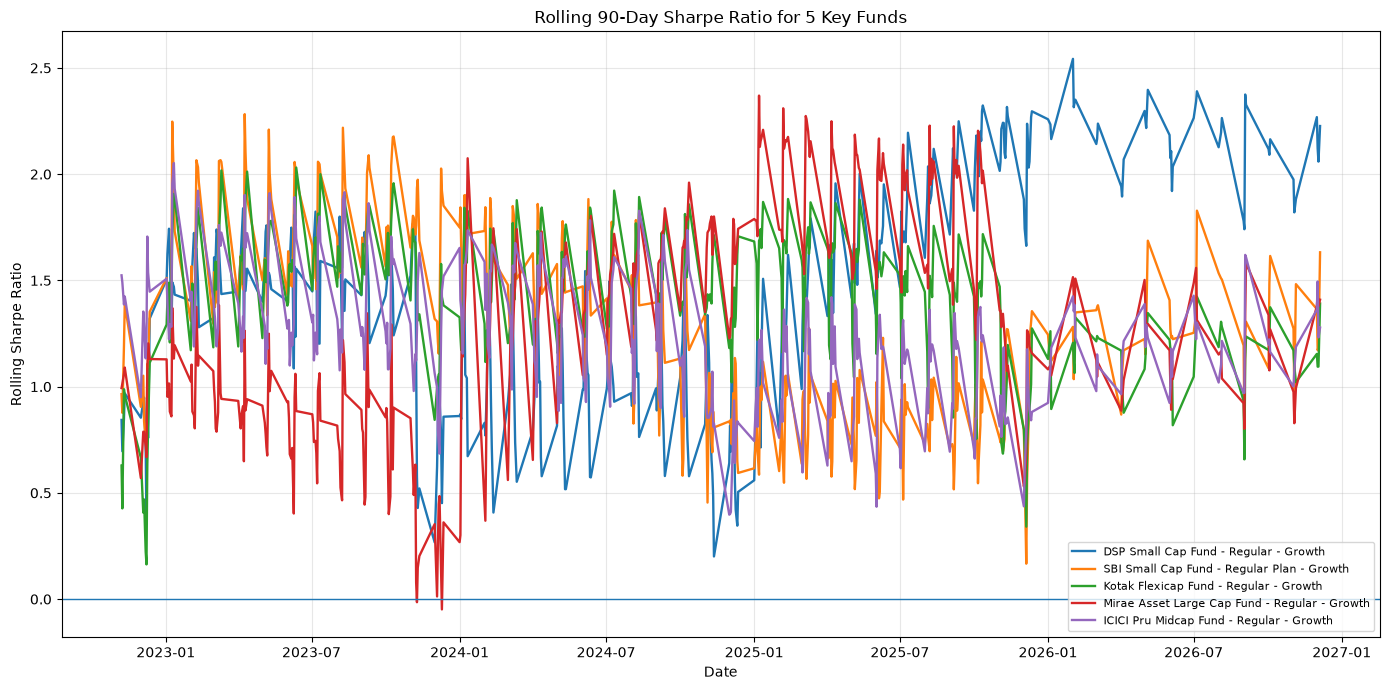

Saved: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\charts\rolling_sharpe_chart.png


In [5]:
ret_wide = returns.pivot(index=nav_date_col, columns=nav_code_col, values="daily_return").sort_index()
rolling_sharpe = (ret_wide.rolling(90).mean() / ret_wide.rolling(90).std()) * SQRT_252

eligible = var_cvar[var_cvar["observations"] >= 90].copy()
eligible = eligible.sort_values("sharpe_ratio", ascending=False).head(5)
key_funds = eligible[nav_code_col].astype(str).tolist()

if len(key_funds) == 0:
    key_funds = var_cvar[nav_code_col].astype(str).head(5).tolist()

name_map = dict(zip(var_cvar[nav_code_col].astype(str), var_cvar["fund_display_name"].astype(str)))

plt.figure(figsize=(14, 7))
for code in key_funds:
    if code in rolling_sharpe.columns:
        plt.plot(
            rolling_sharpe.index,
            rolling_sharpe[code],
            linewidth=1.7,
            label=name_map.get(str(code), str(code))[:45]
        )

plt.axhline(0, linewidth=1)
plt.title("Rolling 90-Day Sharpe Ratio for 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(loc="best", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()

rolling_chart_path = CHART_DIR / "rolling_sharpe_chart.png"
plt.savefig(rolling_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", rolling_chart_path)

## 3. Investor Cohort Analysis

Cohort is based on each investor's **first transaction year**.

In [12]:
if "investor_txn" not in globals():
    print("InvestorTransactions table not found. Skipping investor cohort analysis.")

else:
    tx = investor_txn.copy()

    print("Current investor_txn columns:")
    print(list(tx.columns))

    required_any_cols = ["investor_id", "customer_id", "user_id", "client_id"]

    if not any(col in tx.columns for col in required_any_cols):
        print("\nERROR: investor_txn is not the InvestorTransactions table.")
        print("It looks like you loaded SIPInflows instead.")
        print("Please load the correct InvestorTransactions CSV/table and run again.")

    else:
        investor_col = pick_col(
            tx,
            ["investor_id", "customer_id", "user_id", "client_id"],
            label="investor id"
        )

        txn_date_col = pick_col(
            tx,
            ["date", "transaction_date", "txn_date", "month"],
            label="transaction date"
        )

        txn_code_col = pick_col(
            tx,
            ["amfi_code", "scheme_code", "fund_code"],
            required=False,
            label="transaction fund code"
        )

        amount_col = pick_col(
            tx,
            ["amount_inr", "amount", "sip_amount", "transaction_amount", "investment_amount", "txn_amount"],
            label="amount"
        )

        tx[txn_date_col] = pd.to_datetime(tx[txn_date_col], errors="coerce")
        tx[amount_col] = pd.to_numeric(tx[amount_col], errors="coerce")

        tx = tx.dropna(subset=[investor_col, txn_date_col, amount_col])

        tx["first_transaction_year"] = tx.groupby(investor_col)[txn_date_col].transform("min").dt.year

        cohort_summary = (
            tx.groupby("first_transaction_year")
            .agg(
                investor_count=(investor_col, "nunique"),
                avg_sip_amount=(amount_col, "mean"),
                total_invested=(amount_col, "sum")
            )
            .reset_index()
        )

        if txn_code_col:
            top_fund = (
                tx.groupby(["first_transaction_year", txn_code_col])[amount_col]
                .sum()
                .reset_index()
                .sort_values(["first_transaction_year", amount_col], ascending=[True, False])
                .drop_duplicates("first_transaction_year")
                .rename(columns={txn_code_col: "top_fund_preference"})
            )

            cohort_summary = cohort_summary.merge(
                top_fund[["first_transaction_year", "top_fund_preference"]],
                on="first_transaction_year",
                how="left"
            )

        print("Investor Cohort Analysis:")
        display(cohort_summary)

Current investor_txn columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
Investor Cohort Analysis:


,first_transaction_year,investor_count,avg_sip_amount,total_invested,top_fund_preference
0,2024,4803,107422.541832,3491125187,102885
1,2025,197,109158.577061,30455243,119599


## 4. SIP Continuity Analysis

For investors with **6 or more SIP transactions**, flag as **At-risk** when average gap is greater than 35 days.

In [14]:
sip_report = pd.DataFrame()
continuity_rate = np.nan

if investor_txn.empty:
    print("InvestorTransactions table not found. Skipping SIP continuity analysis.")
else:
    sip = investor_txn.copy()

    investor_col = pick_col(sip, ["investor_id", "customer_id", "user_id", "client_id"], label="investor id")
    txn_date_col = pick_col(sip, ["date", "transaction_date", "txn_date", "month"], label="transaction date")
    amount_col = pick_col(
    sip,
    ["amount_inr", "amount", "sip_amount", "transaction_amount", "investment_amount", "txn_amount"],
    label="amount"
)

    sip[investor_col] = sip[investor_col].astype(str).str.strip()
    sip[txn_date_col] = parse_date_series(sip[txn_date_col])
    sip[amount_col] = to_numeric_series(sip[amount_col])
    sip = sip.dropna(subset=[investor_col, txn_date_col, amount_col])

    type_col = pick_col(sip, ["transaction_type", "txn_type", "type"], required=False, label="transaction type")
    if type_col:
        sip = sip[sip[type_col].astype(str).str.lower().str.contains("sip|systematic", na=False)]

    sip = sip.sort_values([investor_col, txn_date_col])
    sip["gap_days"] = sip.groupby(investor_col)[txn_date_col].diff().dt.days

    sip_counts = (
        sip.groupby(investor_col)
        .agg(
            sip_transactions=(txn_date_col, "count"),
            avg_gap_days=("gap_days", "mean"),
            max_gap_days=("gap_days", "max"),
            avg_sip_amount=(amount_col, "mean"),
            total_sip_amount=(amount_col, "sum")
        )
        .reset_index()
    )

    sip_report = sip_counts[sip_counts["sip_transactions"] >= 6].copy()
    sip_report["continuity_status"] = np.where(
        sip_report["avg_gap_days"] > 35,
        "At-risk",
        "Continuous"
    )

    if len(sip_report) > 0:
        continuity_rate = (sip_report["continuity_status"].eq("Continuous").mean()) * 100

    sip_path = OUTPUT_DIR / "sip_continuity_report.csv"
    sip_report.to_csv(sip_path, index=False)

    print("Saved:", sip_path)
    print(f"SIP continuity rate: {continuity_rate:.2f}%" if pd.notna(continuity_rate) else "No eligible investors found.")
    display(sip_report.head(20))

Saved: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\advanced_analytics\sip_continuity_report.csv
SIP continuity rate: 0.00%


,investor_id,sip_transactions,avg_gap_days,max_gap_days,avg_sip_amount,total_sip_amount,continuity_status
17,INV000023,6,73.200000,173.0,21623.333333,129740,At-risk
66,INV000086,6,49.200000,94.0,9964.000000,59784,At-risk
83,INV000105,6,115.600000,334.0,13898.166667,83389,At-risk
87,INV000109,6,83.600000,296.0,3787.166667,22723,At-risk
114,INV000148,6,61.400000,189.0,10854.000000,65124,At-risk
174,INV000228,7,45.666667,91.0,31943.000000,223601,At-risk
214,INV000279,7,111.500000,326.0,6841.000000,47887,At-risk
345,INV000452,6,108.600000,301.0,11061.000000,66366,At-risk
519,INV000676,8,81.428571,183.0,13689.250000,109514,At-risk
766,INV001002,7,51.333333,97.0,5442.571429,38098,At-risk


## 5. Simple Fund Recommender

Input risk appetite: `Low`, `Moderate`, or `High`.  
Output: top 3 funds by Sharpe ratio within matching `risk_grade`.

In [15]:
def recommend_funds(risk_appetite="Moderate", top_n=3):
    risk_appetite = str(risk_appetite).strip().title()
    valid = ["Low", "Moderate", "High"]
    if risk_appetite not in valid:
        raise ValueError("risk_appetite must be one of: Low, Moderate, High")

    rec = var_cvar.copy()
    rec["risk_grade_clean"] = rec["risk_grade"].astype(str).str.title()
    rec["risk_grade_clean"] = rec["risk_grade_clean"].replace({
        "Medium": "Moderate",
        "Medium Risk": "Moderate",
        "Moderate Risk": "Moderate",
        "Low Risk": "Low",
        "High Risk": "High"
    })

    rec = rec[rec["risk_grade_clean"] == risk_appetite]

    if len(rec) == 0:
        print(f"No exact {risk_appetite} risk-grade funds found. Showing top funds overall.")
        rec = var_cvar.copy()

    rec = rec.sort_values("sharpe_ratio", ascending=False).head(top_n)

    display_cols = [
        "fund_display_name", "risk_grade", "sharpe_ratio", "var_95",
        "cvar_95", "annualized_volatility", "observations"
    ]
    display_cols = [c for c in display_cols if c in rec.columns]
    return rec[display_cols]

recommendation_table = recommend_funds("Moderate", top_n=3)
display(recommendation_table)

,fund_display_name,risk_grade,sharpe_ratio,var_95,cvar_95,annualized_volatility,observations
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.328985,-0.255066,-0.323155,1.587476,452
19,SBI Bluechip Fund - Regular Plan - Growth,Moderate,1.187333,-0.141999,-0.255658,1.348482,452
9,Nippon India Large Cap Fund - Regular - Growth,Moderate,1.090865,-0.158368,-0.243397,1.307768,452


## 6. Sector HHI Concentration

Formula:
\[
HHI = \sum weight_i^2
\]

Higher HHI means a more concentrated portfolio.

In [17]:
hhi_report = pd.DataFrame()

if sector_data.empty:
    print("Sector allocation / holdings CSV not found.")
    print("To calculate HHI, add a CSV with columns like: amfi_code, sector, weight")

    hhi_report = pd.DataFrame(columns=[
        "amfi_code", "fund_display_name", "sector_count", "hhi", "concentration_level"
    ])
    hhi_path = OUTPUT_DIR / "sector_hhi_concentration.csv"
    hhi_report.to_csv(hhi_path, index=False)
    print("Created empty template:", hhi_path)
else:
    sec = sector_data.copy()

    sec_code_col = pick_col(sec, ["amfi_code", "scheme_code", "fund_code"], label="sector fund code")
    sector_col = pick_col(sec, ["sector", "sector_name", "industry"], label="sector")
    weight_col = pick_col(
    sec,
    ["weight_pct", "weight", "allocation", "sector_weight", "percentage", "portfolio_weight"],
    label="sector weight"
)

    sec[sec_code_col] = sec[sec_code_col].astype(str).str.strip()
    sec[sector_col] = sec[sector_col].astype(str).str.strip()
    sec[weight_col] = to_numeric_series(sec[weight_col])
    sec = sec.dropna(subset=[sec_code_col, sector_col, weight_col])

    if sec[weight_col].max() > 1:
        sec[weight_col] = sec[weight_col] / 100

    sec["normalized_weight"] = sec[weight_col] / sec.groupby(sec_code_col)[weight_col].transform("sum")
    sec["weight_square"] = sec["normalized_weight"] ** 2

    hhi_report = (
        sec.groupby(sec_code_col)
        .agg(
            sector_count=(sector_col, "nunique"),
            hhi=("weight_square", "sum"),
            top_sector_weight=("normalized_weight", "max")
        )
        .reset_index()
    )

    def concentration_label(hhi):
        if pd.isna(hhi):
            return "Unknown"
        if hhi < 0.15:
            return "Diversified"
        if hhi < 0.25:
            return "Moderately Concentrated"
        return "Highly Concentrated"

    hhi_report["concentration_level"] = hhi_report["hhi"].apply(concentration_label)

    hhi_report = hhi_report.merge(
        var_cvar[[nav_code_col, "fund_display_name", "risk_grade", "sharpe_ratio"]],
        left_on=sec_code_col,
        right_on=nav_code_col,
        how="left"
    )
    if nav_code_col != sec_code_col and nav_code_col in hhi_report.columns:
        hhi_report = hhi_report.drop(columns=[nav_code_col])

    hhi_report = hhi_report.rename(columns={sec_code_col: "amfi_code"})
    hhi_report = hhi_report.sort_values("hhi", ascending=False)

    hhi_path = OUTPUT_DIR / "sector_hhi_concentration.csv"
    hhi_report.to_csv(hhi_path, index=False)

    print("Saved:", hhi_path)
    display(hhi_report.head(20))

Saved: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\advanced_analytics\sector_hhi_concentration.csv


,amfi_code,sector_count,hhi,top_sector_weight,concentration_level,fund_display_name,risk_grade,sharpe_ratio
11,119092,7,0.206489,0.381838,Moderately Concentrated,Axis Bluechip Fund - Regular - Growth,Moderate,0.580501
3,101207,6,0.200741,0.350735,Moderately Concentrated,ABSL Small Cap Fund - Regular - Growth,Very High,0.871114
18,119599,7,0.174751,0.282500,Moderately Concentrated,SBI Small Cap Fund - Direct Plan - Growth,Very High,0.920911
4,102885,8,0.174709,0.289500,Moderately Concentrated,UTI Nifty 50 Index Fund - Regular - Growth,Moderate,0.918942
7,118632,6,0.168231,0.304339,Moderately Concentrated,Nippon India Large Cap Fund - Regular - Growth,Moderate,1.090865
29,148568,6,0.167963,0.286129,Moderately Concentrated,Mirae Asset Emerging Bluechip Fund - Regular -...,Moderately High,1.083018
21,120505,7,0.157507,0.234553,Moderately Concentrated,ICICI Pru Midcap Fund - Regular - Growth,High,1.323779
22,120506,7,0.153732,0.214657,Moderately Concentrated,ICICI Pru Value Discovery Fund - Regular - Growth,Moderately High,0.908556
27,125498,6,0.152414,0.228300,Moderately Concentrated,HDFC Mid-Cap Opportunities Fund - Direct - Growth,High,0.827989
23,120841,7,0.149650,0.224378,Diversified,Kotak Bluechip Fund - Regular - Growth,Moderate,0.882889


## 7. Advanced Insights for Jupyter Markdown

Run the next cell to auto-generate 5 insights from your actual outputs.

In [19]:
insights = []

if len(var_cvar) > 0:
    worst_var = var_cvar.sort_values("var_95").iloc[0]
    insights.append(
        f"1. **Highest downside VaR risk:** {worst_var['fund_display_name']} has the lowest 95% Historical VaR "
        f"({worst_var['var_95']:.2%}), meaning it experienced the weakest 5th-percentile daily return among the analysed schemes."
    )

if len(var_cvar) > 0:
    worst_cvar = var_cvar.sort_values("cvar_95").iloc[0]
    insights.append(
        f"2. **Worst tail-loss CVaR:** {worst_cvar['fund_display_name']} has the weakest CVaR "
        f"({worst_cvar['cvar_95']:.2%}), showing larger average losses on extreme negative days."
    )

if len(var_cvar) > 0:
    best_sharpe = var_cvar.sort_values("sharpe_ratio", ascending=False).iloc[0]
    insights.append(
        f"3. **Best risk-adjusted fund:** {best_sharpe['fund_display_name']} has the highest Sharpe ratio "
        f"({best_sharpe['sharpe_ratio']:.2f}), indicating stronger return per unit of volatility."
    )

if "cohort_summary" in globals() and isinstance(cohort_summary, pd.DataFrame) and len(cohort_summary) > 0:
    top_cohort = cohort_summary.sort_values("total_invested", ascending=False).iloc[0]

    insights.append(
        f"4. **Strongest investor cohort:** The {int(top_cohort['first_transaction_year'])} cohort invested the most "
        f"with total investments of ₹{top_cohort['total_invested']:,.0f}."
    )
else:
    insights.append(
        "4. **Investor cohort insight:** Investor cohort analysis could not be completed because the investor transaction data was not available or did not match the expected columns."
    )

if isinstance(sip_report, pd.DataFrame) and len(sip_report) > 0 and pd.notna(continuity_rate):
    at_risk_count = int((sip_report["continuity_status"] == "At-risk").sum())
    total_eligible = int(len(sip_report))
    insights.append(
        f"5. **SIP continuity:** Out of {total_eligible} investors with 6+ SIP transactions, "
        f"{at_risk_count} investors are at-risk. Overall SIP continuity rate is {continuity_rate:.2f}%."
    )
elif isinstance(hhi_report, pd.DataFrame) and len(hhi_report) > 0:
    top_hhi = hhi_report.sort_values("hhi", ascending=False).iloc[0]
    insights.append(
        f"5. **Sector concentration:** {top_hhi['fund_display_name']} has the highest HHI "
        f"({top_hhi['hhi']:.3f}), meaning it has the most concentrated sector allocation among analysed equity funds."
    )
else:
    insights.append(
        "5. **SIP / sector concentration insight:** SIP continuity and sector HHI could not be fully completed because the required transaction or sector allocation data was missing."
    )

insights_markdown = "## 5 Advanced Insights\n\n" + "\n\n".join(insights)
display(Markdown(insights_markdown))

insights_path = OUTPUT_DIR / "advanced_insights.md"
with open(insights_path, "w", encoding="utf-8") as f:
    f.write(insights_markdown)

print("Saved:", insights_path)

## 5 Advanced Insights

1. **Highest downside VaR risk:** Axis Midcap Fund - Regular - Growth has the lowest 95% Historical VaR (-25.96%), meaning it experienced the weakest 5th-percentile daily return among the analysed schemes.

2. **Worst tail-loss CVaR:** DSP Small Cap Fund - Regular - Growth has the weakest CVaR (-33.99%), showing larger average losses on extreme negative days.

3. **Best risk-adjusted fund:** DSP Small Cap Fund - Regular - Growth has the highest Sharpe ratio (1.53), indicating stronger return per unit of volatility.

4. **Strongest investor cohort:** The 2024 cohort invested the most with total investments of ₹3,491,125,187.

5. **SIP continuity:** Out of 38 investors with 6+ SIP transactions, 38 investors are at-risk. Overall SIP continuity rate is 0.00%.

Saved: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\advanced_analytics\advanced_insights.md


In [21]:
from pathlib import Path

output_dir = Path(r"C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\advanced_analytics")
output_dir.mkdir(parents=True, exist_ok=True)

cohort_summary.to_csv(output_dir / "investor_cohort_analysis.csv", index=False)

print("Saved:", output_dir / "investor_cohort_analysis.csv")

Saved: C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\advanced_analytics\investor_cohort_analysis.csv


## Final Output Check

Run this cell at the end to confirm all required files exist.

In [22]:
required_outputs = [
    OUTPUT_DIR / "var_cvar_report.csv",
    PROJECT_ROOT / "recommender.py",
    CHART_DIR / "rolling_sharpe_chart.png"
]

optional_outputs = [
    OUTPUT_DIR / "investor_cohort_analysis.csv",
    OUTPUT_DIR / "sip_continuity_report.csv",
    OUTPUT_DIR / "sector_hhi_concentration.csv",
    OUTPUT_DIR / "advanced_insights.md"
]

print("Required deliverables:")
for p in required_outputs:
    print(("✅" if p.exists() else "❌"), p)

print("\nExtra outputs:")
for p in optional_outputs:
    print(("✅" if p.exists() else "❌"), p)

Required deliverables:
✅ C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\advanced_analytics\var_cvar_report.csv
✅ C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\recommender.py
✅ C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\charts\rolling_sharpe_chart.png

Extra outputs:
✅ C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\advanced_analytics\investor_cohort_analysis.csv
✅ C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\advanced_analytics\sip_continuity_report.csv
✅ C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\advanced_analytics\sector_hhi_concentration.csv
✅ C:\Users\BELLANA UPENDRA\OneDrive\All\mutual-fund-analytics\reports\advanced_analytics\advanced_insights.md
